# Analisis Performa Penjualan (Exploratory Sales Analysis)
Notebook ini bertujuan untuk melakukan analisis mendalam terhadap data transaksi ritel guna mendapatkan wawasan bisnis utama:
1. **Executive Overview**: Ringkasan metrik makro (Revenue, Transaksi, Unit Terjual, AOV).
2. **Revenue Bulanan**: Tren omset penjualan dan persentase pertumbuhan bulanan (*MoM Growth*).
3. **Store Performance**: Evaluasi kinerja penjualan antar lokasi toko.
4. **Category Performance**: Pangsa kontribusi penjualan per kategori produk.
5. **Product Performance**: Identifikasi 10 produk unggulan (*Top 10 Products*).
6. **Hourly Pattern**: Pola waktu transaksi per jam operasional (*Peak Hours*).
7. **Day of Week Pattern**: Pola transaksi harian (*Weekday vs Weekend*).

## 0. Setup Environment & Ekstraksi Data
Menghubungkan notebook ke database PostgreSQL, menjalankan query SQL untuk denormalisasi data transaksi, dan memuatnya ke dalam DataFrame Pandas.

In [1]:
from pathlib import Path
import sys
import pandas as pd

# 1. SETUP PATH & MODUL REUSABLE
# Mengambil path direktori induk (root project) dari posisi notebook saat ini
PROJECT_ROOT = Path.cwd().parent

# Menambahkan root project ke sys.path agar modul 'etl' bisa di-import
sys.path.append(str(PROJECT_ROOT))

# Meng-import fungsi engine PostgreSQL dari modul etl/db_connection.py
from etl.db_connection import get_engine

# Menginisialisasi koneksi database
engine = get_engine()


# 2. SQL QUERY (DATA EXTRACTION & DENORMALIZATION)
# Menggabungkan data transaksi (sales_transactions), toko (stores), 
# produk (products), dan kategori (categories) menjadi satu dataset utuh.
# Sekaligus menghitung kalkulasi dasar 'revenue' (qty * unit_price).
query = """
SELECT
    st.store_id,
    st.store_location,
    s.transaction_id,
    s.transaction_date,
    s.transaction_time,
    s.transaction_qty,
    p.product_id,
    p.product_detail,
    c.category_name,
    s.unit_price,
    s.transaction_qty * s.unit_price AS revenue
FROM sales_transactions s
JOIN stores st
    ON s.store_id = st.store_id
JOIN products p
    ON s.product_id = p.product_id
JOIN categories c
    ON p.category_id = c.category_id;
"""


# 3. EKSEKUSI QUERY KE PANDAS DATAFRAME
# Membaca data dari PostgreSQL dan memastikan kolom tanggal bertipe datetime
sales_df = pd.read_sql(query, engine)
sales_df["transaction_date"] = pd.to_datetime(sales_df["transaction_date"])


# 4. INSPEKSI AWAL DATASET
# Menampilkan ringkasan dimensi data dan total pendapatan untuk verifikasi awal
print(f"Total Baris Data  : {len(sales_df):,}")
print(f"Total Kolom Data  : {len(sales_df.columns)}")
print(f"Total Pendapatan  : Rp {sales_df['revenue'].sum():,.2f}")

# Menampilkan 5 baris pertama
sales_df.head()

Total Baris Data  : 149,116
Total Kolom Data  : 11
Total Pendapatan  : Rp 698,812.33


,store_id,store_location,transaction_id,transaction_date,transaction_time,transaction_qty,product_id,product_detail,category_name,unit_price,revenue
0,5,Lower Manhattan,1,2023-01-01,07:06:11,2,32,Ethiopia Rg,Coffee,3.0,6.0
1,5,Lower Manhattan,2,2023-01-01,07:08:56,2,57,Spicy Eye Opener Chai Lg,Tea,3.1,6.2
2,5,Lower Manhattan,3,2023-01-01,07:14:04,2,59,Dark chocolate Lg,Drinking Chocolate,4.5,9.0
3,5,Lower Manhattan,4,2023-01-01,07:20:24,1,22,Our Old Time Diner Blend Sm,Coffee,2.0,2.0
4,5,Lower Manhattan,5,2023-01-01,07:22:41,2,57,Spicy Eye Opener Chai Lg,Tea,3.1,6.2


## 1. Executive Overview (Ringkasan Metrik Utama)
Perhitungan metrik kinerja bisnis utama (*Key Performance Indicators*):
- **Total Revenue**: Total perputaran omset dari seluruh transaksi.
- **Total Transactions**: Jumlah total transaksi unik yang tercatat.
- **Total Items Sold**: Total kuantitas produk yang berhasil terjual.
- **Average Order Value (AOV)**: Nilai rata-rata pembelanjaan dalam setiap transaksi (*Revenue / Transaksi*).

In [2]:
# 1. Menghitung ringkasan metrik utama (KPIs)
total_revenue = sales_df["revenue"].sum()
total_transactions = sales_df["transaction_id"].nunique()
total_items = sales_df["transaction_qty"].sum()
aov = total_revenue / total_transactions

# 2. Menampilkan output ringkasan eksekutif
print(f"Total Revenue      : Rp {total_revenue:,.2f}")
print(f"Total Transactions : {total_transactions:,}")
print(f"Total Items Sold   : {total_items:,}")
print(f"Average Order Value: Rp {aov:,.2f}")

Total Revenue      : Rp 698,812.33
Total Transactions : 149,116
Total Items Sold   : 214,470
Average Order Value: Rp 4.69


## 2. Analisis Pendapatan Bulanan (Monthly Revenue & Growth)
Mengelompokkan transaksi per bulan kalender untuk melihat tren pendapatan, jumlah transaksi, volume unit terjual, serta persentase pertumbuhan bulanan (*Month-over-Month Growth %*).

In [3]:
# 1. Agregasi data penjualan bulanan
monthly_sales = (
    sales_df
    .assign(month=sales_df["transaction_date"].dt.to_period("M").astype(str))
    .groupby("month")
    .agg(
        revenue=("revenue", "sum"),
        transactions=("transaction_id", "nunique"),
        quantity=("transaction_qty", "sum")
    )
    .reset_index()
)

# 2. Menghitung persentase pertumbuhan pendapatan bulanan (MoM Growth %)
monthly_sales["growth"] = (
    monthly_sales["revenue"].pct_change() * 100
)

# Menampilkan tabel hasil penjualan bulanan beserta growth
monthly_sales

,month,revenue,transactions,quantity,growth
0,2023-01,81677.74,17314,24870,NaN
1,2023-02,76145.19,16359,23550,-6.773633
2,2023-03,98834.68,21229,30406,29.797667
3,2023-04,118941.08,25335,36469,20.343466
4,2023-05,156727.76,33527,48233,31.769242
5,2023-06,166485.88,35352,50942,6.226159


### Visualisasi Tren Pendapatan Bulanan
Grafik garis untuk memvisualisasikan tren performa pendapatan bulanan.

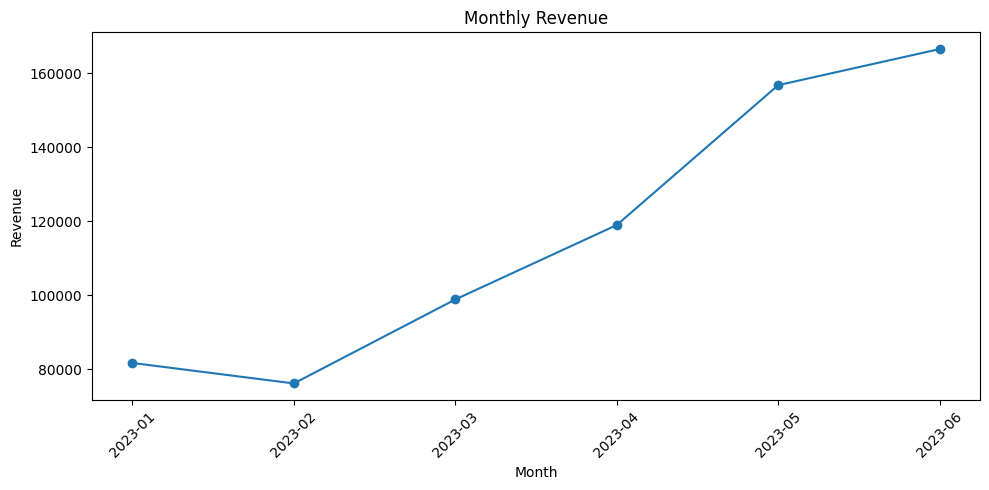

In [4]:
import matplotlib.pyplot as plt

# 1. Inisialisasi ukuran kanvas grafik
plt.figure(figsize=(10, 5))

# 2. Plot data garis pendapatan bulanan
plt.plot(
    monthly_sales["month"],
    monthly_sales["revenue"],
    marker="o"
)

# 3. Memberikan judul, label sumbu, dan rotasi sumbu X
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

# Menampilkan grafik
plt.show()

## 3. Analisis Kinerja Toko (Store Performance)
Mengevaluasi kontribusi pendapatan, volume transaksi, kuantitas produk terjual, serta *Average Order Value* (AOV) untuk setiap lokasi cabang toko.

In [5]:
# 1. Agregasi performa penjualan per toko dan lokasi
store_performance = (
    sales_df
    .groupby(["store_id", "store_location"])
    .agg(
        revenue=("revenue", "sum"),
        transactions=("transaction_id", "nunique"),
        quantity=("transaction_qty", "sum")
    )
    .reset_index()
)

# 2. Menghitung Average Order Value (AOV) per cabang toko
store_performance["aov"] = (
    store_performance["revenue"]
    / store_performance["transactions"]
)

# Menampilkan performa toko diurutkan dari pendapatan tertinggi
store_performance.sort_values(
    "revenue",
    ascending=False
)

,store_id,store_location,revenue,transactions,quantity,aov
2,8,Hell's Kitchen,236511.17,50735,71737,4.661696
0,3,Astoria,232243.91,50599,70991,4.589891
1,5,Lower Manhattan,230057.25,47782,71742,4.814726


## 4. Analisis Kinerja Kategori Produk (Category Performance & Revenue Share)
Mengetahui kontribusi masing-masing kategori produk terhadap total omset melalui perhitungan *Revenue Share %*.

In [6]:
# 1. Agregasi performa penjualan per kategori produk
category_performance = (
    sales_df
    .groupby("category_name")
    .agg(
        revenue=("revenue", "sum"),
        transactions=("transaction_id", "nunique"),
        quantity=("transaction_qty", "sum")
    )
    .reset_index()
)

# 2. Menghitung persentase pangsa pendapatan (Revenue Share %)
category_performance["revenue_share"] = (
    category_performance["revenue"]
    / category_performance["revenue"].sum()
    * 100
)

# Menampilkan performa kategori diurutkan dari kontribusi pendapatan terbesar
category_performance.sort_values(
    "revenue",
    ascending=False
)

,category_name,revenue,transactions,quantity,revenue_share
2,Coffee,269952.45,58416,89250,38.630178
8,Tea,196405.95,45449,69737,28.105679
0,Bakery,82315.64,22796,23214,11.779363
4,Drinking Chocolate,72416.00,11468,17457,10.362725
3,Coffee beans,40085.25,1753,1828,5.736197
1,Branded,13607.00,747,776,1.947161
6,Loose Tea,11213.60,1210,1210,1.604665
5,Flavours,8408.80,6790,10511,1.203299
7,Packaged Chocolate,4407.64,487,487,0.630733


## 5. Analisis Produk Unggulan (Top 10 Product Performance)
Mengidentifikasi 10 produk terlaris yang menghasilkan pendapatan tertinggi, beserta nilai rata-rata per transaksi (*AOV per transaction*).

In [7]:
# 1. Agregasi performa penjualan per produk
product_performance = (
    sales_df
    .groupby(["product_id", "product_detail"])
    .agg(
        revenue=("revenue", "sum"),
        quantity=("transaction_qty", "sum"),
        transactions=("transaction_id", "nunique")
    )
    .reset_index()
)

# 2. Menghitung nilai transaksi rata-rata per produk
product_performance["aov_per_transaction"] = (
    product_performance["revenue"]
    / product_performance["transactions"]
)

# Menampilkan 10 produk dengan total pendapatan tertinggi (Top 10 Products)
product_performance.sort_values(
    "revenue",
    ascending=False
).head(10)

,product_id,product_detail,revenue,quantity,transactions,aov_per_transaction
60,61,Sustainably Grown Organic Lg,21151.75,4453,2961,7.143448
58,59,Dark chocolate Lg,21006.00,4668,3029,6.934962
38,39,Latte Rg,19112.25,4497,2896,6.599534
40,41,Cappuccino Lg,17641.75,4151,2772,6.364268
54,55,Morning Sunrise Chai Lg,17384.00,4346,2830,6.142756
37,38,Latte,17257.50,4602,2990,5.771739
35,36,Jamaican Coffee River Lg,16481.25,4395,2911,5.661714
59,60,Sustainably Grown Organic Rg,16233.75,4329,2842,5.712087
39,40,Cappuccino,15997.50,4266,2793,5.727712
26,27,Brazilian Lg,15109.50,4317,2771,5.452725


## 6. Pola Penjualan Berdasarkan Jam (Hourly Pattern)
Menganalisis sebaran transaksi per jam untuk mengidentifikasi jam-jam sibuk (*peak hours*) operasional toko.

In [8]:
# 1. Ekstraksi informasi jam transaksi dari kolom transaction_time
sales_df["hour"] = (
    sales_df["transaction_time"]
    .apply(lambda x: x.hour)
)

# 2. Agregasi aktivitas penjualan per jam operasional
hourly_sales = (
    sales_df
    .groupby("hour")
    .agg(
        revenue=("revenue", "sum"),
        transactions=("transaction_id", "nunique"),
        quantity=("transaction_qty", "sum")
    )
    .reset_index()
)

# Menampilkan pola penjualan per jam operasional
hourly_sales

,hour,revenue,transactions,quantity
0,6,21900.27,4594,6865
1,7,63526.47,13428,19449
2,8,82699.87,17654,25197
3,9,85169.53,17764,25370
4,10,88673.39,18545,26713
5,11,46319.14,9766,14035
6,12,40192.79,8708,12690
7,13,40367.45,8714,12439
8,14,41304.74,8933,12907
9,15,41733.10,8979,12923


## 7. Pola Penjualan Berdasarkan Hari (Day of Week Pattern)
Menganalisis distribusi penjualan harian dari hari Senin sampai Minggu untuk melihat perbandingan pola belanja hari kerja vs akhir pekan.

In [9]:
# 1. Ekstraksi nomor urut hari (0 = Senin, 6 = Minggu) dan nama hari
sales_df["day_number"] = (
    sales_df["transaction_date"]
    .dt.dayofweek
)

sales_df["day_name"] = (
    sales_df["transaction_date"]
    .dt.day_name()
)

# 2. Agregasi aktivitas penjualan per hari dalam seminggu
daily_pattern = (
    sales_df
    .groupby(["day_number", "day_name"])
    .agg(
        revenue=("revenue", "sum"),
        transactions=("transaction_id", "nunique"),
        quantity=("transaction_qty", "sum")
    )
    .reset_index()
    .sort_values("day_number")
)

# Menampilkan pola penjualan harian terurut dari hari Senin
daily_pattern

,day_number,day_name,revenue,transactions,quantity
0,0,Monday,101677.28,21643,31231
1,1,Tuesday,99455.94,21202,30449
2,2,Wednesday,100313.54,21310,30625
3,3,Thursday,100767.78,21654,31162
4,4,Friday,101373.00,21701,31207
5,5,Saturday,96894.48,20510,29614
6,6,Sunday,98330.31,21096,30182


## Business Insights

Berdasarkan hasil analisis data transaksi penjualan di atas, berikut adalah 5 wawasan bisnis utama (*key business insights*):

1. **Revenue Tren (Pertumbuhan Bulanan)**:
   Revenue meningkat secara konsisten dan signifikan dari Februari (Rp 76,145.19) hingga puncaknya di bulan Juni 2023 (Rp 166,485.88). Tren penjualan mencatatkan pertumbuhan total lebih dari **+118.6%** dalam periode Februari–Juni 2023.

2. **Store dengan Revenue Tertinggi**:
   Store dengan revenue tertinggi adalah **Hell's Kitchen (store_id 8)** dengan total pendapatan sebesar **Rp 236,511.17** (50,735 transaksi), diikuti oleh **Astoria (store_id 3)** sebesar **Rp 232,243.91** (50,599 transaksi), dan **Lower Manhattan (store_id 5)** sebesar **Rp 230,057.25** (47,782 transaksi). Meskipun demikian, Lower Manhattan memiliki *Average Order Value* (AOV) tertinggi yaitu **Rp 4.81** per transaksi.

3. **Category dengan Kontribusi Revenue Terbesar**:
   Category dengan kontribusi revenue terbesar adalah **Coffee** dengan total omset **Rp 269,952.45 (38.63% revenue share)**, disusul oleh **Tea** sebesar **Rp 196,405.95 (28.11% revenue share)**, dan **Bakery** sebesar **Rp 82,315.64 (11.78% revenue share)**. Gabungan kategori Coffee dan Tea mendominasi lebih dari **66.7%** total pendapatan ritel.

4. **Jam dengan Aktivitas Tertinggi**:
   Jam dengan aktivitas tertinggi adalah pada **jam 10:00 (10.00 AM)** dengan mencatatkan **18,545 transaksi** dan total revenue **Rp 88,673.39**. Periode sibuk utama (*morning rush hours*) terkonsentrasi pada rentang jam **08:00 hingga 10:00 pagi** dengan akumulasi lebih dari 53,900 transaksi.

5. **Hari dengan Revenue Tertinggi**:
   Hari dengan revenue tertinggi adalah **Monday (Senin)** dengan total pendapatan **Rp 101,677.28** (21,643 transaksi), diikuti sangat ketat oleh **Friday (Jumat)** sebesar **Rp 101,373.00** (21,701 transaksi). Secara umum, volume penjualan pada hari kerja (*weekdays*) cenderung lebih tinggi dan stabil dibandingkan akhir pekan (*weekend*, dengan hari Sabtu mencatatkan revenue terendah sebesar Rp 96,894.48).